# Bishop's University
## Departmenty of Computer Science
### Programming Languages for DA - CS504
#### Assignement 3 - FALL2023



### Problem:
* Build a Linear regression model for Medical ensurance cost. The dataset consists of age, sex, BMI(body mass index), children, smoker and region (input vraibales), which are independent and **charge** as a dependent output variable.
* The goal is to predict individual medical costs billed by health insurance.

#### 1. Load data from https://github.com/stedy/Machine-Learning-with-R-datasets/blob/master/insurance.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.metrics import mean_squared_error

# insurance.csv comes from the stedy/Machine-Learning-with-R-datasets repository
df = pd.read_csv('insurance.csv')

#### 2. Show some rows



In [2]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### 3. Plot charges with respect to BMI

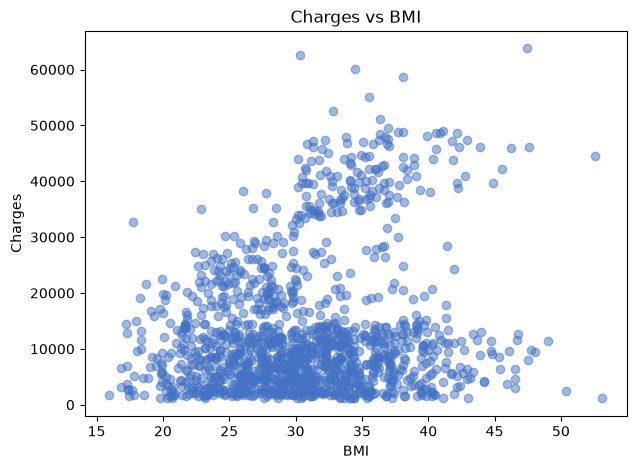

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(df['bmi'], df['charges'], alpha=0.5, color='#4472C4')
plt.xlabel('BMI'); plt.ylabel('Charges')
plt.title('Charges vs BMI')
plt.show()

#### 4. Plot charges with respect to Age

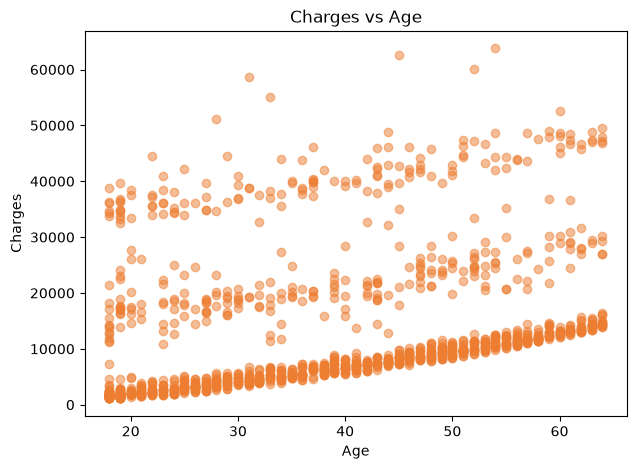

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(df['age'], df['charges'], alpha=0.5, color='#ED7D31')
plt.xlabel('Age'); plt.ylabel('Charges')
plt.title('Charges vs Age')
plt.show()

#### 5. Encode no-numerical variables

In [5]:
# Label-encode the categorical columns so every variable is numeric
df_enc = df.copy()
for col in ['sex', 'smoker', 'region']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])
df_enc.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


#### 6. Scale the variables using MinMax scaler

In [6]:
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_enc), columns=df_enc.columns)
df_scaled.head()

,age,sex,bmi,children,smoker,region,charges
0,0.021739,0.0,0.321227,0.0,1.0,1.000000,0.251611
1,0.000000,1.0,0.479150,0.2,0.0,0.666667,0.009636
2,0.217391,1.0,0.458434,0.6,0.0,0.666667,0.053115
3,0.326087,1.0,0.181464,0.0,0.0,0.333333,0.333010
4,0.304348,1.0,0.347592,0.0,0.0,0.333333,0.043816


#### 7. Split the dataset into Training (70%) and Testing sets

In [7]:
X = df_scaled.drop(columns='charges')
y = df_scaled['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (936, 6) | Test: (402, 6)


### 8. Display correlation matrix between variables based on training set

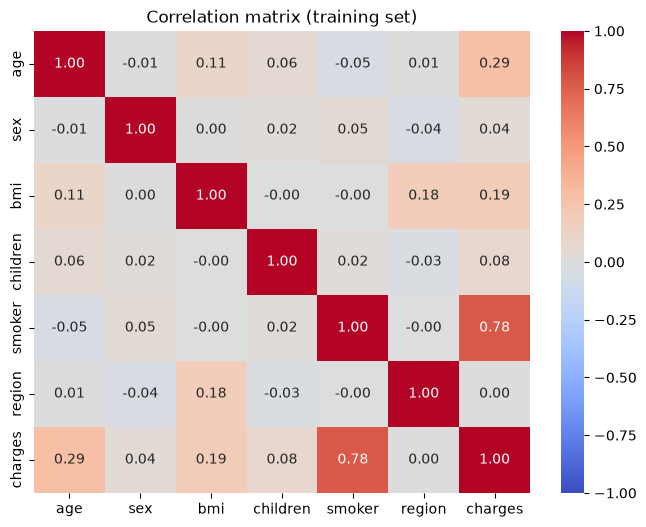

In [8]:
train_df = X_train.copy()
train_df['charges'] = y_train

plt.figure(figsize=(8, 6))
sns.heatmap(train_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix (training set)')
plt.show()

#### 9. Find out the 1st three most correlated input variable to the output variable.

In [9]:
corr_with_charges = train_df.corr()['charges'].drop('charges').abs().sort_values(ascending=False)
top3 = corr_with_charges.head(3)
print('Three most correlated inputs with charges:')
print(top3)
top3_vars = top3.index.tolist()

Three most correlated inputs with charges:
smoker    0.778989
age       0.288804
bmi       0.194264
Name: charges, dtype: float64


#### 10. Train a linear regression using the 3 most correlated input variables

In [10]:
lr = LinearRegression()
lr.fit(X_train[top3_vars], y_train)
print('Coefficients:', dict(zip(top3_vars, np.round(lr.coef_, 4))))
print('Intercept:', round(lr.intercept_, 4))

Coefficients: {'smoker': np.float64(0.3777), 'age': np.float64(0.194), 'bmi': np.float64(0.1972)}
Intercept: -0.0498


#### 11. Compute the error

In [11]:
train_pred = lr.predict(X_train[top3_vars])
mse_train = mean_squared_error(y_train, train_pred)
print('Linear regression - training MSE:', round(mse_train, 6))

Linear regression - training MSE: 0.009722


#### 12. Test the regression model learned in 11) in Testing set then compute the error.

In [12]:
test_pred = lr.predict(X_test[top3_vars])
mse_test = mean_squared_error(y_test, test_pred)
print('Linear regression - testing MSE:', round(mse_test, 6))

Linear regression - testing MSE: 0.00876


#### 13. Train a LASSO regression model based on training set

In [13]:
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train, y_train)
print('LASSO coefficients:')
print(pd.Series(lasso.coef_, index=X.columns).round(4))

LASSO coefficients:
age         0.0949
sex         0.0000
bmi         0.0000
children    0.0000
smoker      0.3132
region      0.0000
dtype: float64


#### 14. Compute the Error

In [14]:
lasso_train_mse = mean_squared_error(y_train, lasso.predict(X_train))
print('LASSO - training MSE:', round(lasso_train_mse, 6))

LASSO - training MSE: 0.012468


#### 15. Using Cross-vaidation algorithm, find the most important input variable and display their weights (coefficients)

In [15]:
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_train, y_train)
print('Best lambda (alpha) from CV:', round(lasso_cv.alpha_, 6))

weights = pd.Series(lasso_cv.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print('\nWeights (most important first):')
print(weights.round(4))
print('\nMost important input variable:', weights.abs().idxmax())

Best lambda (alpha) from CV: 0.000132

Weights (most important first):
smoker      0.3762
bmi         0.1990
age         0.1910
children    0.0318
region     -0.0143
sex         0.0013
dtype: float64

Most important input variable: smoker


#### 16. Disply the chnage of the weights (coefficient) with respect ot Lambda parameters

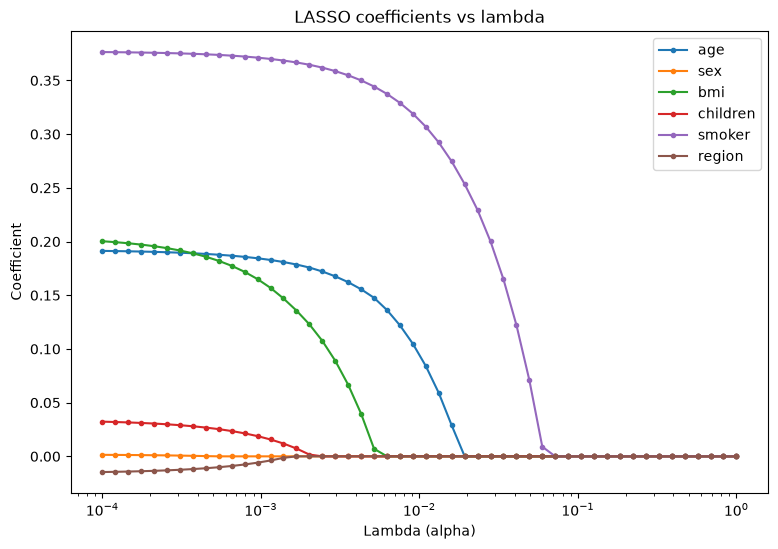

In [16]:
alphas = np.logspace(-4, 0, 50)
coef_path = np.array([Lasso(alpha=a, max_iter=10000).fit(X_train, y_train).coef_ for a in alphas])

plt.figure(figsize=(9, 6))
for i, col in enumerate(X.columns):
    plt.plot(alphas, coef_path[:, i], marker='.', label=col)
plt.xscale('log')
plt.xlabel('Lambda (alpha)'); plt.ylabel('Coefficient')
plt.title('LASSO coefficients vs lambda')
plt.legend()
plt.show()

#### 17. Test the best LASSO regression model found in 16) using Testing set

In [17]:
best_lasso = lasso_cv
best_test_pred = best_lasso.predict(X_test)
print('Predicted (first 5):', np.round(best_test_pred[:5], 4))

Predicted (first 5): [0.1247 0.0957 0.5715 0.1348 0.4129]


#### 18. Compute the Error

In [18]:
best_test_mse = mean_squared_error(y_test, best_lasso.predict(X_test))
print('Best LASSO - testing MSE:', round(best_test_mse, 6))
print('Best LASSO - testing R2 :', round(best_lasso.score(X_test, y_test), 4))

Best LASSO - testing MSE: 0.008609
Best LASSO - testing R2 : 0.7695
